In [ ]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
sphere = Hypersphere(2)




In [ ]:
n_samples = 5000
rho = 1e-5
all_Ms = [3,5,7,9]

all_num_modes =  [1, 2, 3, 4]
all_kappas = [50,100,150,200]
all_sigma2s = [0.01, 0.025, 0.05, .1, .25]

NMC = 10


all_records = []  # Collect all data across num_modes
for num_modes, kappa, M  in zip(all_num_modes, all_kappas, all_Ms):
    G_params = {'kappa': kappa , 'num_modes': num_modes} 
    for sigma2 in all_sigma2s:
        loss_Ts, loss_Ns = [], []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave = False ):
            Theta = S2_multimodal_prior(n_samples, G_params)
            X = sphere.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
            loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
            delta = denoiser('S2', X, M, rho, sigma2, X, )
            loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean() 
            loss_Ts.append(loss_T); loss_Ns.append(loss_N)
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "mc": np.arange(NMC),
            "Denoised": loss_Ts,
            "Naïve": loss_Ns
        }))

df = pd.concat(all_records, ignore_index=True)
df_long = df.melt(id_vars=["num_modes", "sigma2", "mc"], value_vars=["Denoised", "Naïve"],var_name="Loss Type",value_name="Loss")
df_box = (df_long.pivot(index=["num_modes", "sigma2", "mc"],columns="Loss Type",values="Loss").reset_index())
df_box["rel_impr"] = (1 - df_box["Denoised"] / df_box["Naïve"]) * 100



modes=3, σ²=0.01:  40%|████      | 4/10 [00:46<01:09, 11.64s/it]  

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categori

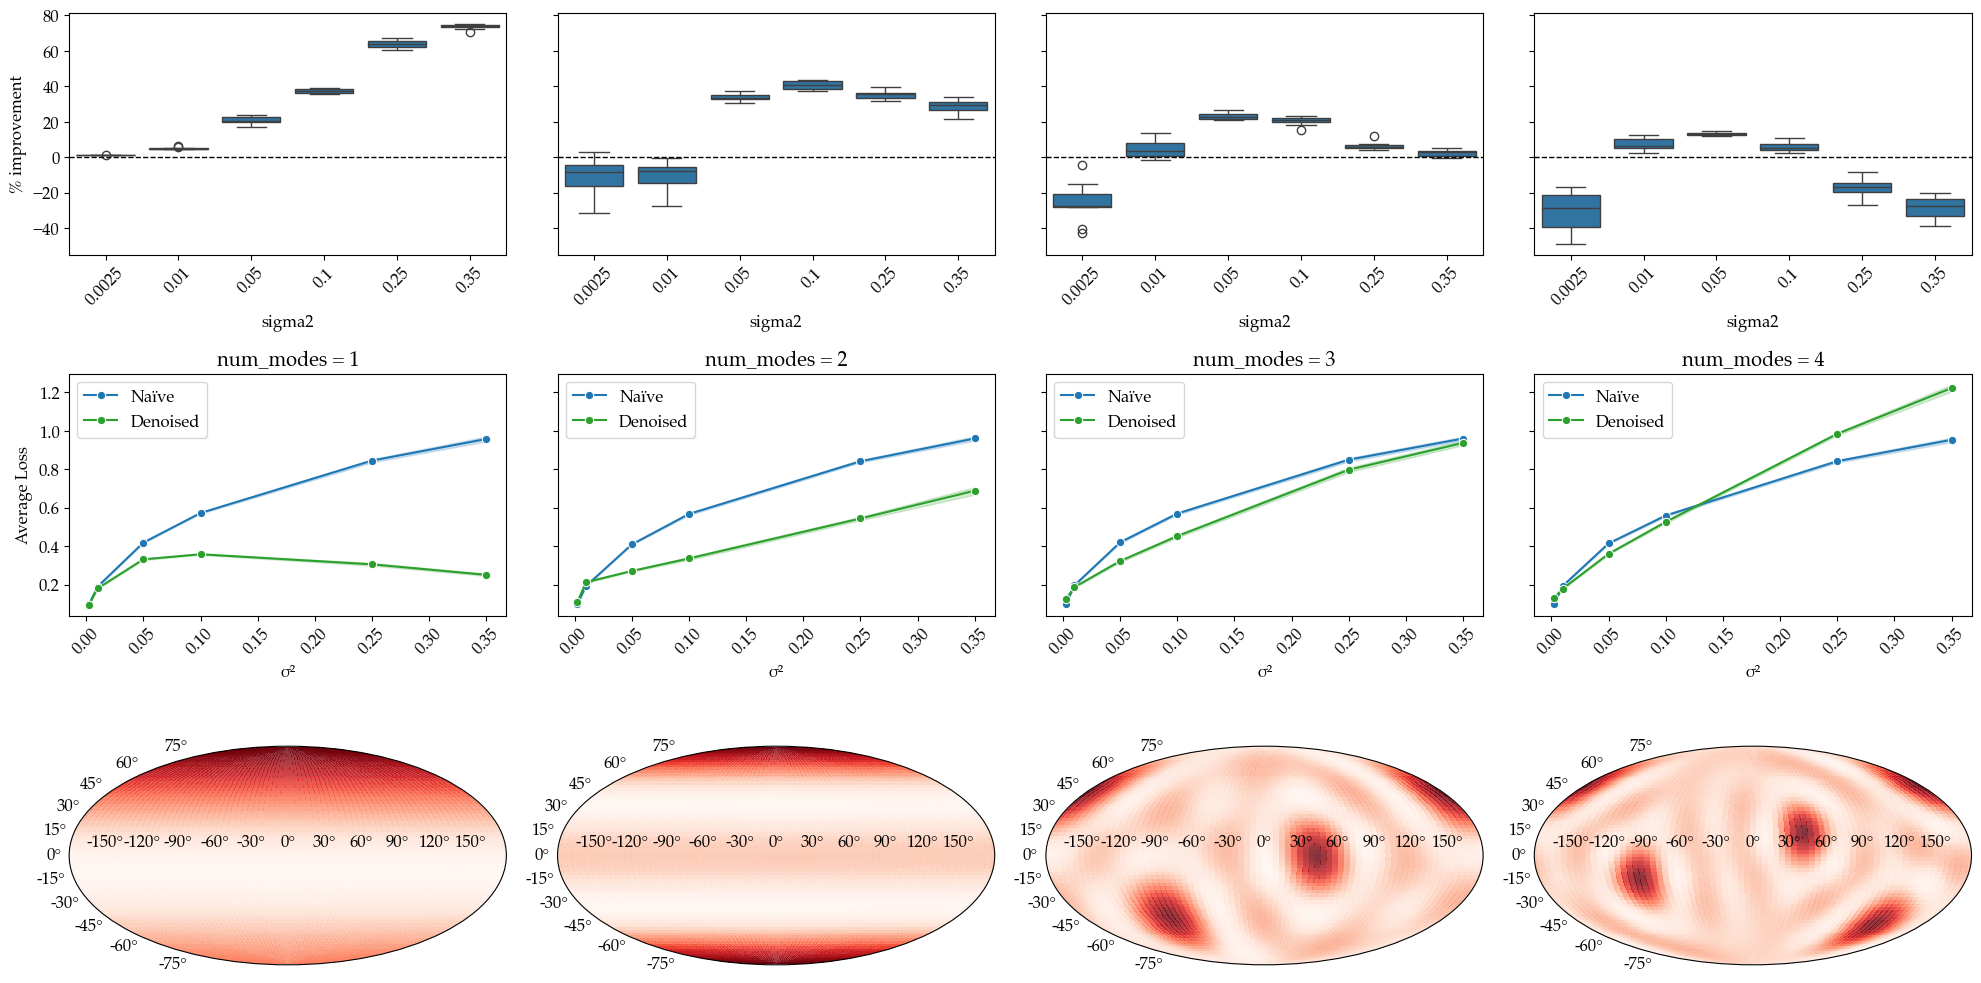

In [ ]:
fig, axs = plt.subplots(3, len(all_num_modes), figsize=(20, 10))

for idx, (num_modes, kappa, M ) in enumerate(zip(all_num_modes, all_kappas, all_Ms)):
    df_subset = df_long[df_long['num_modes'] == num_modes]



    sns.boxplot(
    data=df_box[df_box["num_modes"] == num_modes],
        x='sigma2',
        y='rel_impr',
        ax=axs[0, idx]
    )
    axs[0, idx].axhline(0, ls='--', c='k', lw=1)
    axs[0, idx].set_ylabel('% improvement')
    axs[0, idx].tick_params(axis='x', rotation=45)


    sns.lineplot(
        data=df_subset,
        x="sigma2",
        y="Loss",
        hue="Loss Type",
        hue_order=["Naïve", "Denoised"],
        palette={"Naïve": "C0", "Denoised": "C2"},
        estimator="mean",
        errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
        marker="o",
        ax=axs[1, idx],
    )

    axs[1, idx].set_title(f"num_modes = {num_modes}")
    axs[1, idx].set_xlabel("σ²")
    axs[1, idx].set_ylabel("Average Loss")
    axs[1, idx].tick_params(axis='x', rotation=45)
    

    axs[2, idx].remove()
    axs[2, idx] = fig.add_subplot(
        3, len(all_num_modes), 2 * len(all_num_modes) + idx + 1,
        projection="mollweide"
    )
    axs[1, idx].legend(loc="upper left", frameon=True, title=None)

    Theta = S2_multimodal_prior(  n_samples, {'kappa': kappa, 'num_modes': num_modes})
    grid_resolution = 75
    # theta = np.arccos(Theta[:, 2]); phi   = np.arctan2(Theta[:, 1], Theta[:, 0])  
    # H, theta_edges, phi_edges = np.histogram2d(theta, phi, bins=grid_resolution,     range=[[0, np.pi], [-np.pi, np.pi]]  )
    # axs[2, idx].pcolormesh(phi_edges,np.pi/2 - theta_edges,H,shading="auto",cmap="Reds")
    grid, grid_theta, grid_phi = S2grid(grid_resolution)
    _, hat_f, grad_hat_f, = density_estimate('S2', Theta, M, grid)
    im = axs[2, idx].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Reds')


    # Share y-axes across rows and hide repeated y tick labels within each row
    for r in range(axs.shape[0]-1):
        base = axs[r, 0]
        for c in range(1, axs.shape[1]):
            axs[r, c].sharey(base)
            axs[r, c].set_ylabel("")
            axs[r, c].tick_params(labelleft=False)
plt.tight_layout()
plt.show()